# Table of contents
1. package
2. data import
3. fit in DBSCAN, and set ipywidgets for simple dashboard
4. difference version of DBSCAN and fine tune

    4.1 DBSCAN, DBSCAN+SNN and HDBSCAN with optuna for opt

5. quality test

    5.1 without label, DBCV. 

    5.2 with label, ARI.
----

----
# 1. Load Package, and seed lock

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
import hdbscan

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

locked_sampler = TPESampler(seed=67) # reason unknown so far, it's not working

----
# 2. Data Cleaning & Read data

In [10]:
def load_data(x):
    X = pd.read_csv(f"/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/project_1/{x}.csv",
                    index_col=0,  # truly have to be careful of this type of trivial bugs...
                    )
    
    X_d = X[["Annual Income (k$)", "Spending Score (1-100)"]]
    # X_d = X[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_d)

    return X_scaled
X_scaled = load_data("Mall_Customers")


---
# 3. fit in DBSCAN, and set ipywidgets for simple dashboard

In [ ]:
# @interact(
#     eps=widgets.FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05, description='eps:'),
#     min_samples=widgets.IntSlider(value=5, min=2, max=20, step=1, description='min_samples:')
# )
# def explore_dbscan(eps, min_samples):
#     dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#     labels = dbscan.fit_predict(X_scaled)
    
#     fig = plt.figure(figsize=(24, 8))    
#     ax = fig.add_subplot(111, projection='3d')
#     is_noise = (labels == -1)
#     is_cluster = (labels != -1)
    
#     ax.scatter(X_scaled[is_cluster, 0], 
#                 X_scaled[is_cluster, 1],
#                 X_scaled[is_cluster, 2],
#                 c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

#     ax.scatter(X_scaled[is_noise, 0], 
#                 X_scaled[is_noise, 1],
#                 X_scaled[is_noise, 2],
#                 c='black', marker='x', s=40, label='Noise (-1)')
    
#     ax.set_title(f"3D DBSCAN (eps={eps}, min_samples={min_samples})")
#     ax.set_xlabel("Age")
#     ax.set_ylabel("Annual Income (k$)")
#     ax.set_zlabel("Spending Score (1-100)")
#     ax.legend()
#     plt.show()
    
#     # "Age", "Annual Income (k$)", "Spending Score (1-100)"
#     print(f"Total dots: {len(X_scaled)}")
#     print(f"core dots : {len(dbscan.core_sample_indices_)}")
#     print(f"noise dots: {np.sum(is_noise)}")

----
# 4.1. DBSCAN, with Optuna

eps, min_samples

In [24]:
def objective(trial):
    eps = trial.suggest_float('eps', 0.2, 2.0)
    min_samples = trial.suggest_int('min_samples', 7, 30)
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan.fit_predict(X_scaled)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels):  # that make sure it's bigger than 2 cluster!!
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize", sampler=locked_sampler)
study.optimize(objective, n_trials=500, n_jobs=-1)
29
print("DBSCAN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")

DBSCAN, with Optuna
Best paras:         {'eps': 0.3701652364946414, 'min_samples': 8}
Highest DBCV:       0.3160


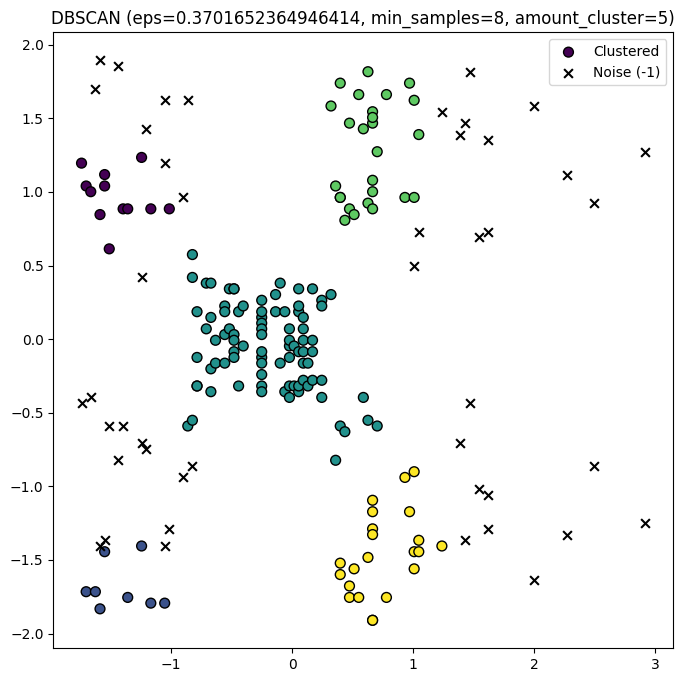

Silhouette score (for reference only): 0.3390


In [25]:
def labels_and_plot_dbscan(eps, min_samples, X_scaled):

    dbscan_snn = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan_snn.fit_predict(X_scaled)

    amount_cluster = int(max(labels)) +1

    is_noise = (labels == -1)
    is_cluster = (labels != -1)

    plt.figure(figsize=(8, 8))

    plt.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1], 
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    plt.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1], 
                c='black', marker='x', s=40, label='Noise (-1)')

    plt.title(f"DBSCAN (eps={eps}, min_samples={min_samples}, amount_cluster={amount_cluster})")
    plt.legend()
    plt.show()

    return labels
dbscan_labels = labels_and_plot_dbscan(0.3701652364946414, 8, X_scaled)

sil_score = silhouette_score(X_scaled, dbscan_labels)
print(f"Silhouette score (for reference only): {sil_score:.4f}")

In [7]:
def objective(trial):
    eps = trial.suggest_float('eps', 0.2, 1.5)
    min_samples = trial.suggest_int('min_samples', 8, 30)
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan.fit_predict(X_scaled)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize", sampler=locked_sampler)
study.optimize(objective, n_trials=50)

print("DBSCAN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")

DBSCAN, with Optuna
Best paras:         {'eps': 0.4376771723728185, 'min_samples': 18}
Highest DBCV:       0.2998


IndexError: index 2 is out of bounds for axis 1 with size 2

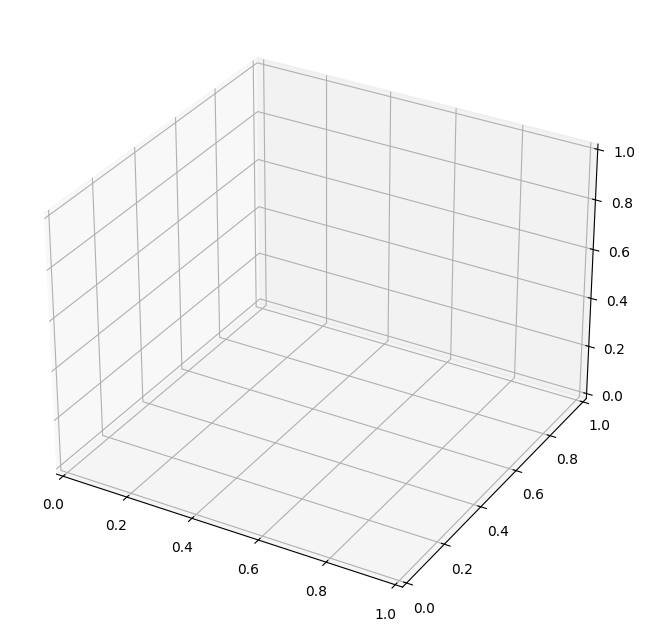

In [8]:
def labels_and_plot_dbscan(eps, min_samples, X_scaled):

    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = dbscan.fit_predict(X_scaled)

    cluster_amount = int(labels.max()) + 1

    is_noise = (labels == -1)
    is_cluster = (labels != -1)
    
    fig = plt.figure(figsize=(12, 8))    
    ax = fig.add_subplot(111, projection='3d')
    is_noise = (labels == -1)
    is_cluster = (labels != -1)
    
    ax.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1],
                X_scaled[is_cluster, 2],
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    ax.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1],
                X_scaled[is_noise, 2],
                c='black', marker='x', s=40, label='Noise (-1)')
    
    ax.set_title(f"3D DBSCAN (eps={eps:.4}, min_samples={min_samples}, cluster_amount={cluster_amount})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Annual Income (k$)")
    ax.set_zlabel("Spending Score (1-100)")
    ax.legend()
    plt.show()

    return labels
dbscan_labels = labels_and_plot_dbscan(0.5457335233738585, 9, X_scaled)

----
# 4.2. DBSCAN + SNN, with Optuna

to deal with these 2 specific problems, we have to trade off to have 3 hyper-parameter

uneven density, high dimention

k, eps, min_samples

In [66]:
def objective(trial):
    k = trial.suggest_int('k', 10, 25)
    eps = trial.suggest_int('eps', 9, 20)
    min_samples = trial.suggest_int('min_samples', 7, 30)
    
    nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')
    snn_distance = k - (graph @ graph.T).toarray()
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = dbscan.fit_predict(snn_distance)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=500, n_jobs=-1)

print("DBSCAN + SNN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")


DBSCAN + SNN, with Optuna
Best paras:         {'k': 12, 'eps': 9, 'min_samples': 29}
Highest DBCV:       0.2625


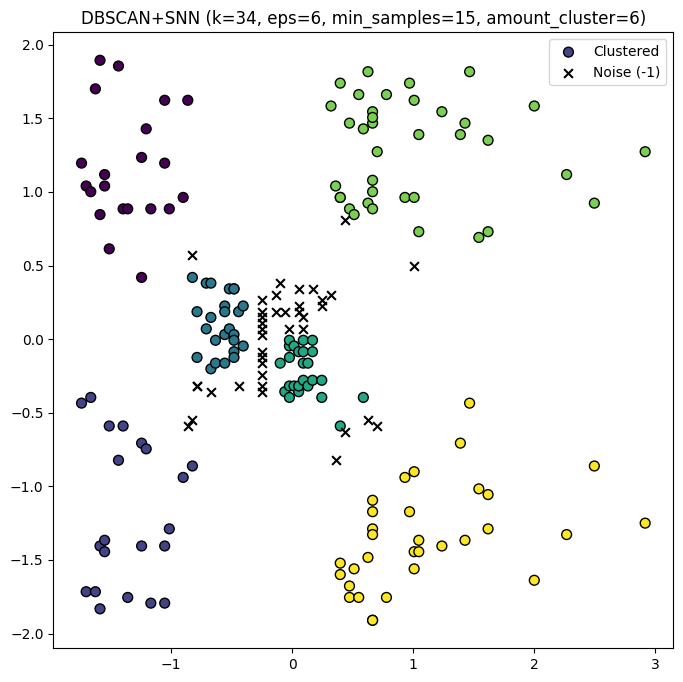

Silhouette score (for reference only): 0.3692
0.3480592179193722


In [75]:
def labels_and_plot_dbscan_snn(k,eps,min_samples,X_scaled):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')  # the connectivity here, will the amount of k neighbors, making a set of each member who contained or not eg. {0,1,0}

    snn_similarity = (graph @ graph.T).toarray() # the amount of common friends for each dot
    snn_distance = k - snn_similarity

    dbscan_snn = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = dbscan_snn.fit_predict(snn_distance)

    amount_cluster = int(max(labels)) +1

    is_noise = (labels == -1)
    is_cluster = (labels != -1)

    plt.figure(figsize=(8, 8))

    plt.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1], 
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    plt.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1], 
                c='black', marker='x', s=40, label='Noise (-1)')

    plt.title(f"DBSCAN+SNN (k={k}, eps={eps}, min_samples={min_samples}, amount_cluster={amount_cluster})")
    plt.legend()
    plt.show()

    return labels
# dbscan_snn_labels = labels_and_plot_dbscan_snn(21,10,20, X_scaled)
dbscan_snn_labels = labels_and_plot_dbscan_snn(34,6,15, X_scaled)


sil_score = silhouette_score(X_scaled, dbscan_snn_labels)
print(f"Silhouette score (for reference only): {sil_score:.4f}")


nn = NearestNeighbors(n_neighbors=34).fit(X_scaled)
graph = nn.kneighbors_graph(X_scaled, mode='connectivity')
snn_distance = 34 - (graph @ graph.T).toarray()
dbscan = DBSCAN(eps=6, min_samples=15, metric='precomputed')
labels = dbscan.fit_predict(snn_distance)
dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
print(dbcv_score)

In [ ]:
def objective(trial):
    k = trial.suggest_int('k', 10, 30)
    eps = trial.suggest_int('eps', int(k * 0.3), int(k * 0.7))
    min_samples = trial.suggest_int('min_samples', 8, 25)
    
    nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')
    snn_distance = k - (graph @ graph.T).toarray()
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = dbscan.fit_predict(snn_distance)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("DBSCAN + SNN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")


In [ ]:
def labels_and_plot_dbscan_snn(k,eps,min_samples,X_scaled):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')  # the connectivity here, will the amount of k neighbors, making a set of each member who contained or not eg. {0,1,0}

    snn_similarity = (graph @ graph.T).toarray() # the amount of common friends for each dot
    snn_distance = k - snn_similarity

    dbscan_snn = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = dbscan_snn.fit_predict(snn_distance)

    cluster_amount = int(labels.max()) + 1

    is_noise = (labels == -1)
    is_cluster = (labels != -1)
    
    fig = plt.figure(figsize=(12, 8))    
    ax = fig.add_subplot(111, projection='3d')
    is_noise = (labels == -1)
    is_cluster = (labels != -1)
    
    ax.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1],
                X_scaled[is_cluster, 2],
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    ax.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1],
                X_scaled[is_noise, 2],
                c='black', marker='x', s=40, label='Noise (-1)')
    
    ax.set_title(f"DBSCAN + SNN (k={k},eps={eps}, min_samples={min_samples}, cluster_amount={cluster_amount})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Annual Income (k$)")
    ax.set_zlabel("Spending Score (1-100)")
    ax.legend()
    plt.show()

    return labels
dbscan_snn_labels = labels_and_plot_dbscan_snn(10,5,13, X_scaled)

----
# 4.3. HDBSCAN, with Optuna

pros, uneven density

corns, even but weird shape

min_cluster_size, min_samples

In [30]:
def objective(trial):
    min_cluster_size = trial.suggest_int('min_cluster_size', 3, 20)
    min_samples = trial.suggest_int('min_samples', 7, 30)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples,
        core_dist_n_jobs=-1 
    )
    labels = clusterer.fit_predict(X_scaled)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5000, n_jobs=-1)

print("HDBSCAN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")

HDBSCAN, with Optuna
Best paras:         {'min_cluster_size': 7, 'min_samples': 7}
Highest DBCV:       0.3255


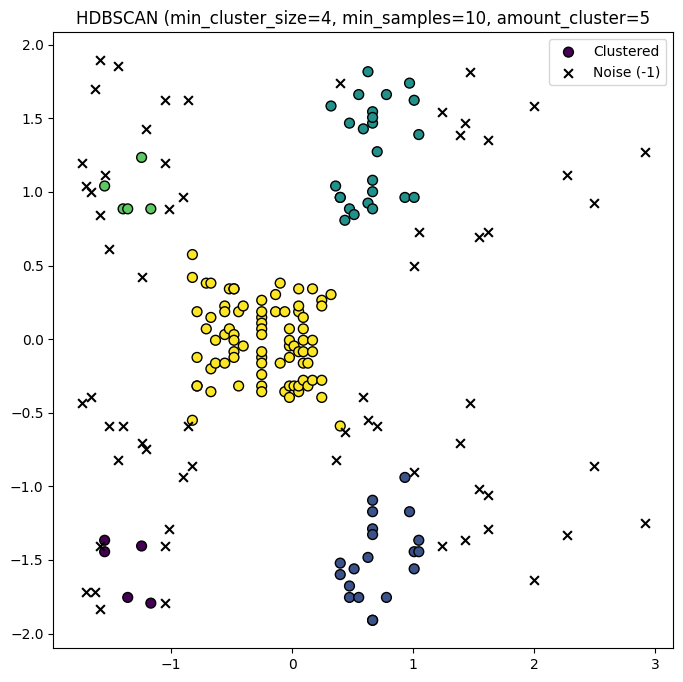

Silhouette score (for reference only): 0.2237


In [27]:
def labels_and_plot_hdbscan(min_cluster_size,min_samples,X_scaled):

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples,
        core_dist_n_jobs=-1 
    )
    labels = clusterer.fit_predict(X_scaled)

    amount_cluster = int(max(labels)) +1


    is_noise = (labels == -1)
    is_cluster = (labels != -1)

    plt.figure(figsize=(8, 8))

    plt.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1], 
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    plt.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1], 
                c='black', marker='x', s=40, label='Noise (-1)')

    plt.title(f"HDBSCAN (min_cluster_size={min_cluster_size}, min_samples={min_samples}, amount_cluster={amount_cluster}")
    plt.legend()
    plt.show()

    return labels
hdbscan_labels = labels_and_plot_hdbscan(4,10, X_scaled)

sil_score = silhouette_score(X_scaled, hdbscan_labels)
print(f"Silhouette score (for reference only): {sil_score:.4f}")

In [ ]:
def objective(trial):
    min_cluster_size = trial.suggest_int('min_cluster_size', 8, 30)
    min_samples = trial.suggest_int('min_samples', 1, min_cluster_size)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples,
        core_dist_n_jobs=-1 
    )
    labels = clusterer.fit_predict(X_scaled)
    
    # for avoid NaN data, that optuna's error-prevention gives
    if len(set(labels)) < 2 or (len(set(labels)) == 2 and -1 in labels): 
        return -1.0
        
    try:
        dbcv_score = hdbscan.validity.validity_index(X_scaled, labels)
        return dbcv_score
    except ValueError:
        return -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("HDBSCAN, with Optuna")
print(f"Best paras:         {study.best_params}")
print(f"Highest DBCV:       {study.best_value:.4f}")

In [ ]:
def labels_and_plot_hdbscan(min_cluster_size,min_samples,X_scaled):

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples,
        core_dist_n_jobs=-1 
    )
    labels = clusterer.fit_predict(X_scaled)

    cluster_amount = int(labels.max()) + 1

    is_noise = (labels == -1)
    is_cluster = (labels != -1)
    
    fig = plt.figure(figsize=(12, 8))    
    ax = fig.add_subplot(111, projection='3d')
    is_noise = (labels == -1)
    is_cluster = (labels != -1)
    
    ax.scatter(X_scaled[is_cluster, 0], 
                X_scaled[is_cluster, 1],
                X_scaled[is_cluster, 2],
                c=labels[is_cluster], cmap='viridis', s=50, edgecolor='k', label='Clustered')

    ax.scatter(X_scaled[is_noise, 0], 
                X_scaled[is_noise, 1],
                X_scaled[is_noise, 2],
                c='black', marker='x', s=40, label='Noise (-1)')
    
    ax.set_title(f"3D DBSCAN (min_cluster_size={min_cluster_size}, min_samples={min_samples}, cluster_amount={cluster_amount})")
    ax.set_xlabel("Age")
    ax.set_ylabel("Annual Income (k$)")
    ax.set_zlabel("Spending Score (1-100)")
    ax.legend()
    plt.show()

    return labels
hdbscan_labels = labels_and_plot_hdbscan(9,3, X_scaled)

----
# 5. quality test